<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/RVA_study161225.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
from scipy import stats

In [42]:
df = pd.read_excel('/content/drive/MyDrive/AK and AR 1wk, 6wk and 3 months 011225.xlsx')

In [43]:
sheets = pd.ExcelFile('/content/drive/MyDrive/AK and AR 1wk, 6wk and 3 months 011225.xlsx')
sheets.sheet_names

['raw data', 'data 1wk, 6wk and 3 months', 'sorted data']

In [44]:
sorted_data = sheets.parse('sorted data')

In [45]:
sorted_data.columns

Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk ', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth'],
      dtype='object')

In [46]:
# Strip column names
sorted_data.columns = sorted_data.columns.str.strip()

In [47]:
sorted_data.isnull().sum()

,0
Age,0
Gender,0
PreopR1,0
PreopR2,0
PreopA1,0
Sph1wk,2
Cyl1wk,41
Axis1wk,41
Sph6wk,1
Cyl6wk,3


In [48]:
sorted_data.dropna(subset=['Sph3mth', 'Cyl3mth',
       'Axis3mth'], inplace=True)
sorted_data.isnull().sum()

,0
Age,0
Gender,0
PreopR1,0
PreopR2,0
PreopA1,0
Sph1wk,2
Cyl1wk,23
Axis1wk,23
Sph6wk,0
Cyl6wk,0


In [49]:
sorted_data.dropna(subset=['Sph1wk', 'Cyl1wk',
       'Axis1wk'], inplace=True)
sorted_data.isnull().sum()

,0
Age,0
Gender,0
PreopR1,0
PreopR2,0
PreopA1,0
Sph1wk,0
Cyl1wk,0
Axis1wk,0
Sph6wk,0
Cyl6wk,0


In [50]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth'],
      dtype='object')

### Overall age extended descriptive statistics

In [51]:
age = sorted_data['Age'].dropna()

count = age.count()
mean = age.mean()
sd = age.std(ddof=1)
se = sd / np.sqrt(count)
min_val = age.min()
max_val = age.max()
skew = age.skew()
kurtosis = age.kurt()

# 95% confidence interval for the mean
ci_low, ci_high = stats.t.interval(
    0.95, df=count-1, loc=mean, scale=se
)

age_stats = pd.DataFrame({
    'count': [count],
    'mean': [mean],
    'SD': [sd],
    'SE': [se],
    'min': [min_val],
    'max': [max_val],
    'skew': [skew],
    'kurtosis': [kurtosis],
    '95% CI low': [ci_low],
    '95% CI high': [ci_high]
})

age_stats


,count,mean,SD,SE,min,max,skew,kurtosis,95% CI low,95% CI high
0,87,63.505747,9.481774,1.016553,38,84,-0.157963,-0.305004,61.484907,65.526587


### Age by gender

In [52]:
def descriptive_stats(series):
    series = series.dropna()
    n = series.count()
    mean = series.mean()
    sd = series.std(ddof=1)
    se = sd / np.sqrt(n)
    skew = series.skew()
    kurt = series.kurt()
    ci_low, ci_high = stats.t.interval(
        0.95, df=n-1, loc=mean, scale=se
    )

    return pd.Series({
        'count': n,
        'mean': mean,
        'SD': sd,
        'SE': se,
        'min': series.min(),
        'max': series.max(),
        'skew': skew,
        'kurtosis': kurt,
        '95% CI low': ci_low,
        '95% CI high': ci_high
    })

age_by_gender = (
    sorted_data
    .groupby('Gender')['Age']
    .apply(descriptive_stats)
    .round(2)
)

age_by_gender


Gender             
F       count          53.00
        mean           63.11
        SD              8.94
        SE              1.23
        min            46.00
        max            83.00
        skew            0.01
        kurtosis       -0.58
        95% CI low     60.65
        95% CI high    65.58
M       count          34.00
        mean           64.12
        SD             10.38
        SE              1.78
        min            38.00
        max            84.00
        skew           -0.39
        kurtosis        0.06
        95% CI low     60.50
        95% CI high    67.74
Name: Age, dtype: float64

In [53]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth'],
      dtype='object')

In [54]:
sorted_data['Preop_cylinder'] = sorted_data['PreopR2'] - sorted_data['PreopR1']
sorted_data['Preop_meanK'] = (sorted_data['PreopR1'] + sorted_data['PreopR2']) /2

In [55]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth', 'Preop_cylinder', 'Preop_meanK'],
      dtype='object')

In [56]:
# Columns of interest
cols = ['Preop_cylinder', 'Preop_meanK']

# Function to compute descriptive stats
def descriptive_stats(series):
    series = series.dropna()
    n = len(series)
    mean = series.mean()
    median = series.median()
    sd = series.std(ddof=1)
    se = sd / np.sqrt(n)
    min_val = series.min()
    max_val = series.max()
    skew = series.skew()
    kurt = series.kurtosis()

    # 95% CI
    ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)

    return pd.Series({
        'n': n,
        'mean': round(mean,2),
        'SD': round(sd,2),
        'median': round(median,2),
        'SE': round(se,2),
        'min': round(min_val,2),
        'max': round(max_val,2),
        'skew': round(skew,2),
        'kurtosis': round(kurt,2),
        '95% CI': f"{round(ci_low,2)} - {round(ci_high,2)}"
    })

# Apply to each column
descriptive_table = sorted_data[cols].apply(descriptive_stats)
descriptive_table


,Preop_cylinder,Preop_meanK
n,87,87
mean,0.86,44.89
SD,0.6,1.57
median,0.75,44.88
SE,0.06,0.17
min,0.0,40.75
max,3.0,49.0
skew,1.25,0.05
kurtosis,1.54,-0.04
95% CI,0.74 - 0.99,44.55 - 45.22


In [57]:
from scipy.stats import shapiro

stat, p = shapiro(sorted_data['Preop_cylinder'].dropna())
print("Shapiro–Wilk:", stat, "p =", p)


Shapiro–Wilk: 0.8864625911321864 p = 1.4911310543753758e-06


In [58]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth', 'Preop_cylinder', 'Preop_meanK'],
      dtype='object')

In [59]:
import numpy as np

# Corneal cylinder
sorted_data['C'] = sorted_data['PreopR2'] - sorted_data['PreopR1']

# Mean corneal power
sorted_data['M'] = (sorted_data['PreopR1'] + sorted_data['PreopR2']) / 2

# Convert axis to radians
axis_rad = np.deg2rad(sorted_data['PreopA1'])

# J0 and J45
sorted_data['J0'] = -0.5 * sorted_data['C'] * np.cos(2 * axis_rad)
sorted_data['J45'] = -0.5 * sorted_data['C'] * np.sin(2 * axis_rad)
sorted_data

,Age,Gender,PreopR1,PreopR2,PreopA1,Sph1wk,Cyl1wk,Axis1wk,Sph6wk,Cyl6wk,Axis6wk,Sph3mth,Cyl3mth,Axis3mth,Preop_cylinder,Preop_meanK,C,M,J0,J45
0,54,F,46.50,47.25,155,0.25,-1.50,115.0,0.25,-1.25,100.0,0.50,-1.00,65.0,0.75,46.875,0.75,46.875,-0.241045,2.872667e-01
1,63,F,46.75,48.00,80,0.75,-2.25,80.0,0.75,-2.00,90.0,0.50,-2.00,80.0,1.25,47.375,1.25,47.375,0.587308,-2.137626e-01
3,71,F,45.25,45.75,120,-0.75,-1.00,160.0,-0.5,-0.75,140.0,-0.50,-0.50,150.0,0.50,45.500,0.50,45.500,0.125000,2.165064e-01
5,59,F,42.50,43.50,75,2,-2.00,90.0,1.75,-2.00,80.0,1.75,-2.25,80.0,1.00,43.000,1.00,43.000,0.433013,-2.500000e-01
7,63,F,43.00,44.50,90,-1,-0.50,100.0,-0.5,-2.25,80.0,-0.50,-1.50,70.0,1.50,43.750,1.50,43.750,0.750000,-9.184851e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,59,F,46.75,47.50,10,-2.25,-3.50,70.0,-2,-3.25,90.0,-2.25,-3.25,120.0,0.75,47.125,0.75,47.125,-0.352385,-1.282576e-01
162,69,F,44.75,46.75,55,0.75,1.00,50.0,0.5,0.50,75.0,0.25,0.50,110.0,2.00,45.750,2.00,45.750,0.342020,-9.396926e-01
163,66,F,43.25,44.00,60,-2.75,-3.00,60.0,-2.5,-3.00,95.0,-2.00,-3.00,90.0,0.75,43.625,0.75,43.625,0.187500,-3.247595e-01
166,52,F,42.00,42.50,110,-0.75,-1.25,95.0,-0.5,-1.00,60.0,-0.50,-1.25,75.0,0.50,42.250,0.50,42.250,0.191511,1.606969e-01


In [60]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth', 'Preop_cylinder', 'Preop_meanK', 'C', 'M', 'J0', 'J45'],
      dtype='object')

In [61]:
import numpy as np

# Cylinder magnitude
sorted_data['C_mag'] = 2 * np.sqrt(
    sorted_data['J0']**2 + sorted_data['J45']**2
)

# Axis (flat meridian), degrees 0–180
sorted_data['Axis'] = 0.5 * np.degrees(
    np.arctan2(sorted_data['J45'], sorted_data['J0'])
)

# Ensure axis is positive
sorted_data.loc[sorted_data['Axis'] < 0, 'Axis'] += 180

theta = np.deg2rad(2 * sorted_data['Axis'])  # radians
r = sorted_data['C_mag']


In [62]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth', 'Preop_cylinder', 'Preop_meanK', 'C', 'M', 'J0', 'J45',
       'C_mag', 'Axis'],
      dtype='object')

In [63]:
# Columns of interest
cols = ['J0', 'J45']

# Function to compute descriptive stats
def descriptive_stats(series):
    series = series.dropna()
    n = len(series)
    mean = series.mean()
    median = series.median()
    sd = series.std(ddof=1)
    se = sd / np.sqrt(n)
    min_val = series.min()
    max_val = series.max()
    skew = series.skew()
    kurt = series.kurtosis()

    # 95% CI
    ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)

    return pd.Series({
        'n': n,
        'mean': round(mean,2),
        'SD': round(sd,2),
        'median': round(median,2),
        'SE': round(se,2),
        'min': round(min_val,2),
        'max': round(max_val,2),
        'skew': round(skew,2),
        'kurtosis': round(kurt,2),
        '95% CI': f"{round(ci_low,2)} - {round(ci_high,2)}"
    })

# Apply to each column
descriptive_table = sorted_data[cols].apply(descriptive_stats)
descriptive_table


,J0,J45
n,87,87
mean,0.07,0.01
SD,0.42,0.32
median,0.09,0.0
SE,0.04,0.03
min,-1.12,-1.41
max,0.86,1.25
skew,-0.57,-0.48
kurtosis,0.64,6.31
95% CI,-0.02 - 0.16,-0.06 - 0.08


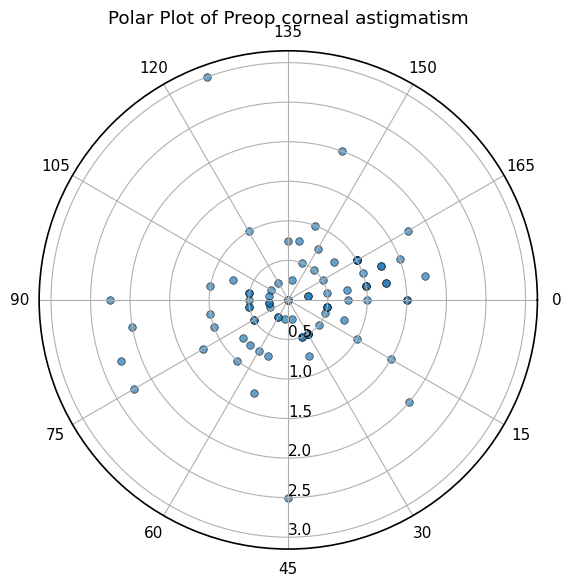

In [64]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.2
})

fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)

# Scatter plot
ax.scatter(
    theta,
    r,
    s=30,
    alpha=0.7,
    edgecolors='k',
    linewidth=0.5
)

# Axis settings
ax.set_theta_zero_location('E')   # 0° at horizontal
ax.set_theta_direction(-1)        # clockwise
ax.set_thetagrids(range(0, 360, 30), labels=range(0, 180, 15))
ax.set_rlabel_position(90)

ax.set_title("Polar Plot of Preop corneal astigmatism", pad=20)

plt.tight_layout()
plt.show()


In [65]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth', 'Preop_cylinder', 'Preop_meanK', 'C', 'M', 'J0', 'J45',
       'C_mag', 'Axis'],
      dtype='object')

In [66]:
sorted_data

,Age,Gender,PreopR1,PreopR2,PreopA1,Sph1wk,Cyl1wk,Axis1wk,Sph6wk,Cyl6wk,...,Cyl3mth,Axis3mth,Preop_cylinder,Preop_meanK,C,M,J0,J45,C_mag,Axis
0,54,F,46.50,47.25,155,0.25,-1.50,115.0,0.25,-1.25,...,-1.00,65.0,0.75,46.875,0.75,46.875,-0.241045,2.872667e-01,0.75,65.0
1,63,F,46.75,48.00,80,0.75,-2.25,80.0,0.75,-2.00,...,-2.00,80.0,1.25,47.375,1.25,47.375,0.587308,-2.137626e-01,1.25,170.0
3,71,F,45.25,45.75,120,-0.75,-1.00,160.0,-0.5,-0.75,...,-0.50,150.0,0.50,45.500,0.50,45.500,0.125000,2.165064e-01,0.50,30.0
5,59,F,42.50,43.50,75,2,-2.00,90.0,1.75,-2.00,...,-2.25,80.0,1.00,43.000,1.00,43.000,0.433013,-2.500000e-01,1.00,165.0
7,63,F,43.00,44.50,90,-1,-0.50,100.0,-0.5,-2.25,...,-1.50,70.0,1.50,43.750,1.50,43.750,0.750000,-9.184851e-17,1.50,180.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,59,F,46.75,47.50,10,-2.25,-3.50,70.0,-2,-3.25,...,-3.25,120.0,0.75,47.125,0.75,47.125,-0.352385,-1.282576e-01,0.75,100.0
162,69,F,44.75,46.75,55,0.75,1.00,50.0,0.5,0.50,...,0.50,110.0,2.00,45.750,2.00,45.750,0.342020,-9.396926e-01,2.00,145.0
163,66,F,43.25,44.00,60,-2.75,-3.00,60.0,-2.5,-3.00,...,-3.00,90.0,0.75,43.625,0.75,43.625,0.187500,-3.247595e-01,0.75,150.0
166,52,F,42.00,42.50,110,-0.75,-1.25,95.0,-0.5,-1.00,...,-1.25,75.0,0.50,42.250,0.50,42.250,0.191511,1.606969e-01,0.50,20.0


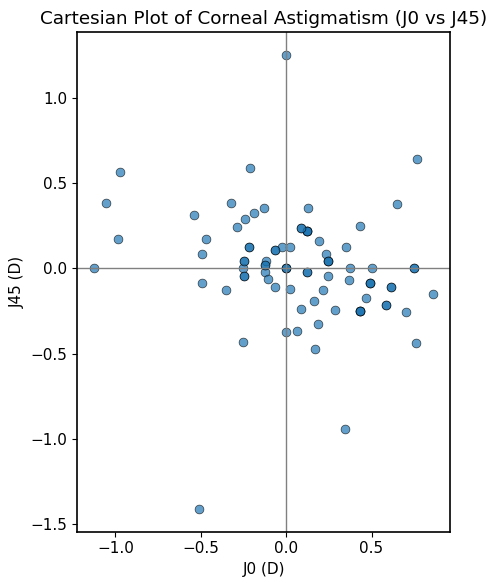

In [67]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.2
})

fig, ax = plt.subplots(figsize=(6, 6))

# Scatter
ax.scatter(
    sorted_data['J0'],
    sorted_data['J45'],
    s=40,
    alpha=0.7,
    edgecolors='k',
    linewidth=0.5
)

# Zero lines
ax.axhline(0, color='gray', linewidth=1)
ax.axvline(0, color='gray', linewidth=1)

# Equal scaling (critical)
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel('J0 (D)')
ax.set_ylabel('J45 (D)')
ax.set_title('Cartesian Plot of Corneal Astigmatism (J0 vs J45)')

plt.tight_layout()
plt.show()


In [68]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth', 'Preop_cylinder', 'Preop_meanK', 'C', 'M', 'J0', 'J45',
       'C_mag', 'Axis'],
      dtype='object')

Astigmatism Axis Classification:
WTR (With-The-Rule):
Axis 0°–30° or 150°–180°
The steepest meridian is vertical.
ATR (Against-The-Rule):
Axis 60°–120°
The steepest meridian is horizontal.
Oblique:
Axis 30°–60° or 120°–150°

In [69]:
import pandas as pd
import numpy as np

def classify_astigmatism(axis):
    if (0 <= axis <= 30) or (150 <= axis <= 180):
        return 'WTR'
    elif 60 <= axis <= 120:
        return 'ATR'
    else:  # 30 < axis < 60 or 120 < axis < 150
        return 'Oblique'

# Apply the function to the 'Axis' column
sorted_data['Astigmatism_Type'] = sorted_data['Axis'].apply(classify_astigmatism)

# Check the results
sorted_data


,Age,Gender,PreopR1,PreopR2,PreopA1,Sph1wk,Cyl1wk,Axis1wk,Sph6wk,Cyl6wk,...,Axis3mth,Preop_cylinder,Preop_meanK,C,M,J0,J45,C_mag,Axis,Astigmatism_Type
0,54,F,46.50,47.25,155,0.25,-1.50,115.0,0.25,-1.25,...,65.0,0.75,46.875,0.75,46.875,-0.241045,2.872667e-01,0.75,65.0,ATR
1,63,F,46.75,48.00,80,0.75,-2.25,80.0,0.75,-2.00,...,80.0,1.25,47.375,1.25,47.375,0.587308,-2.137626e-01,1.25,170.0,WTR
3,71,F,45.25,45.75,120,-0.75,-1.00,160.0,-0.5,-0.75,...,150.0,0.50,45.500,0.50,45.500,0.125000,2.165064e-01,0.50,30.0,WTR
5,59,F,42.50,43.50,75,2,-2.00,90.0,1.75,-2.00,...,80.0,1.00,43.000,1.00,43.000,0.433013,-2.500000e-01,1.00,165.0,WTR
7,63,F,43.00,44.50,90,-1,-0.50,100.0,-0.5,-2.25,...,70.0,1.50,43.750,1.50,43.750,0.750000,-9.184851e-17,1.50,180.0,WTR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,59,F,46.75,47.50,10,-2.25,-3.50,70.0,-2,-3.25,...,120.0,0.75,47.125,0.75,47.125,-0.352385,-1.282576e-01,0.75,100.0,ATR
162,69,F,44.75,46.75,55,0.75,1.00,50.0,0.5,0.50,...,110.0,2.00,45.750,2.00,45.750,0.342020,-9.396926e-01,2.00,145.0,Oblique
163,66,F,43.25,44.00,60,-2.75,-3.00,60.0,-2.5,-3.00,...,90.0,0.75,43.625,0.75,43.625,0.187500,-3.247595e-01,0.75,150.0,WTR
166,52,F,42.00,42.50,110,-0.75,-1.25,95.0,-0.5,-1.00,...,75.0,0.50,42.250,0.50,42.250,0.191511,1.606969e-01,0.50,20.0,WTR


In [70]:
# Count of each astigmatism type
counts = sorted_data['Astigmatism_Type'].value_counts()

# Percentage of each type
percentages = sorted_data['Astigmatism_Type'].value_counts(normalize=True) * 100

# Combine into a single DataFrame
summary = pd.DataFrame({'Count': counts, 'Percentage': percentages.round(2)})

print(summary)


                  Count  Percentage
Astigmatism_Type                   
WTR                  40       45.98
ATR                  32       36.78
Oblique              15       17.24


In [71]:
import pandas as pd
import numpy as np

def classify_vector(J0, J45):
    if abs(J45) >= abs(J0):
        return 'Oblique'
    elif J0 > 0:
        return 'WTR'
    else:  # J0 < 0
        return 'ATR'

# Apply classification to the dataframe
sorted_data['Astig_Vector_Type'] = sorted_data.apply(
    lambda row: classify_vector(row['J0'], row['J45']), axis=1
)

# Count and percentage
counts = sorted_data['Astig_Vector_Type'].value_counts()
percentages = sorted_data['Astig_Vector_Type'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Count': counts, 'Percentage': percentages.round(2)})
print(summary)


                   Count  Percentage
Astig_Vector_Type                   
WTR                   34       39.08
Oblique               31       35.63
ATR                   22       25.29


In [72]:
# Create a confusion matrix
validation_table = pd.crosstab(
    sorted_data['Astigmatism_Type'],
    sorted_data['Astig_Vector_Type'],
    rownames=['Axis-based'],
    colnames=['Vector-based'],
    margins=True  # Optional: adds row/column totals
)

print(validation_table)


Vector-based  ATR  Oblique  WTR  All
Axis-based                          
ATR            22       10    0   32
Oblique         0       15    0   15
WTR             0        6   34   40
All            22       31   34   87


In [73]:
from sklearn.metrics import cohen_kappa_score

# Cohen's kappa
kappa = cohen_kappa_score(sorted_data['Astigmatism_Type'], sorted_data['Astig_Vector_Type'])
print(f"Cohen's kappa: {kappa:.3f}")


Cohen's kappa: 0.724


In [74]:
per_class_agreement = (sorted_data['Astigmatism_Type'] == sorted_data['Astig_Vector_Type']).groupby(sorted_data['Astigmatism_Type']).mean() * 100
print(per_class_agreement)


Astigmatism_Type
ATR         68.75
Oblique    100.00
WTR         85.00
dtype: float64


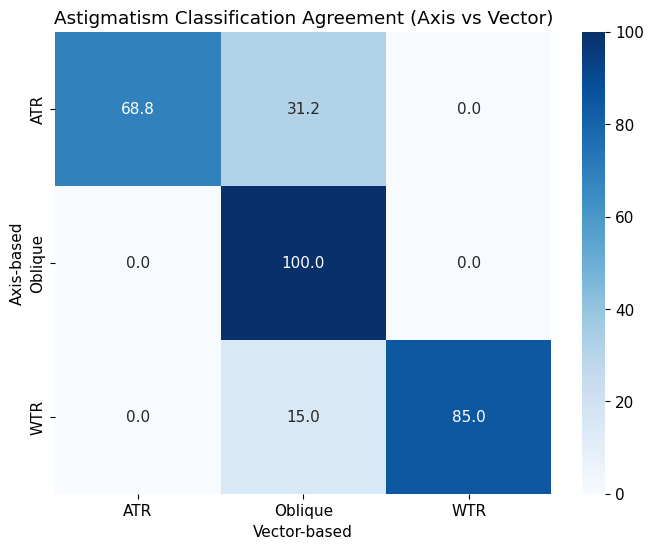

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix (counts)
conf_matrix = pd.crosstab(
    sorted_data['Astigmatism_Type'],
    sorted_data['Astig_Vector_Type'],
    rownames=['Axis-based'],
    colnames=['Vector-based']
)

# Convert counts to percentages per row
conf_matrix_percent = conf_matrix.div(conf_matrix.sum(axis=1), axis=0) * 100

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix_percent, annot=True, fmt=".1f", cmap="Blues")
plt.title('Astigmatism Classification Agreement (Axis vs Vector)')
plt.ylabel('Axis-based')
plt.xlabel('Vector-based')
plt.show()


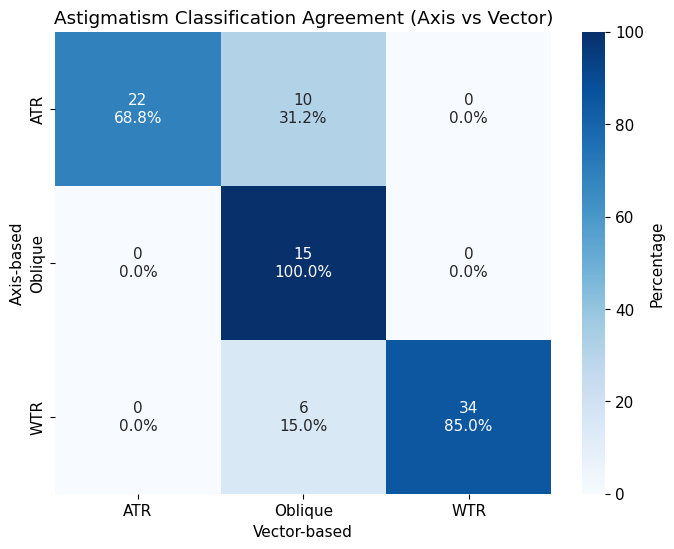

In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix (counts)
conf_matrix = pd.crosstab(
    sorted_data['Astigmatism_Type'],
    sorted_data['Astig_Vector_Type'],
    rownames=['Axis-based'],
    colnames=['Vector-based']
)

# Percentages per row
conf_matrix_percent = conf_matrix.div(conf_matrix.sum(axis=1), axis=0) * 100

# Combine counts and percentages as strings for annotation
annot = conf_matrix.astype(str) + "\n" + conf_matrix_percent.round(1).astype(str) + "%"

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix_percent, annot=annot, fmt='', cmap="Blues", cbar_kws={'label': 'Percentage'})
plt.title('Astigmatism Classification Agreement (Axis vs Vector)')
plt.ylabel('Axis-based')
plt.xlabel('Vector-based')
plt.show()


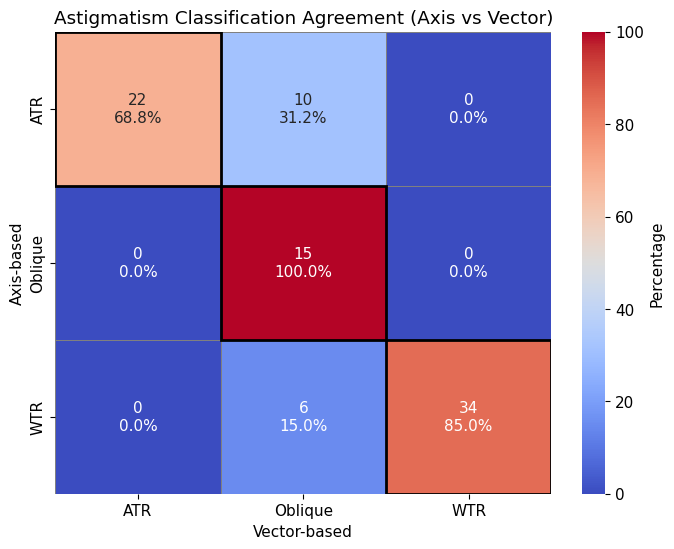

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix (counts)
conf_matrix = pd.crosstab(
    sorted_data['Astigmatism_Type'],
    sorted_data['Astig_Vector_Type'],
    rownames=['Axis-based'],
    colnames=['Vector-based']
)

# Percentages per row
conf_matrix_percent = conf_matrix.div(conf_matrix.sum(axis=1), axis=0) * 100

# Combine counts and percentages for annotation
annot = conf_matrix.astype(str) + "\n" + conf_matrix_percent.round(1).astype(str) + "%"

# Create a mask for diagonal (agreement)
mask_diag = np.eye(conf_matrix.shape[0], dtype=bool)

# Custom colormap: blue for agreement, orange for misclassification
cmap = sns.color_palette(["#FFB347", "#3399FF"])  # orange -> misclassified, blue -> agreement

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    conf_matrix_percent,
    annot=annot,
    fmt='',
    cmap="coolwarm",
    cbar_kws={'label': 'Percentage'},
    linewidths=0.5,
    linecolor='gray'
)

# Optionally, emphasize agreement cells with thicker border
for i in range(conf_matrix.shape[0]):
    plt.gca().add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='black', lw=2))

plt.title('Astigmatism Classification Agreement (Axis vs Vector)')
plt.ylabel('Axis-based')
plt.xlabel('Vector-based')
plt.show()
